In [ ]:
import tensorflow as tf
from  tensorflow import keras
from tensorflow.keras import layers

In [ ]:
cifar10=keras.datasets.cifar10
(x_train,y_train),(x_test,y_test)=cifar10.load_data()
x_train,x_test=x_train/255.0,x_test/255.0

In [ ]:
from tensorflow.keras import models
model=models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(10,activation='softmax'))

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
his=model.fit(x_train,y_train,validation_split=0.1,epochs=5)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 73s 51ms/step - accuracy: 0.4525 - loss: 1.5033 - val_accuracy: 0.5602 - val_loss: 1.2308
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.5902 - loss: 1.1551 - val_accuracy: 0.6162 - val_loss: 1.0925
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.6439 - loss: 1.0089 - val_accuracy: 0.6620 - val_loss: 0.9554
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 50ms/step - accuracy: 0.6824 - loss: 0.9032 - val_accuracy: 0.6720 - val_loss: 0.9326
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 50ms/step - accuracy: 0.7106 - loss: 0.8296 - val_accuracy: 0.6980 - val_loss: 0.8651


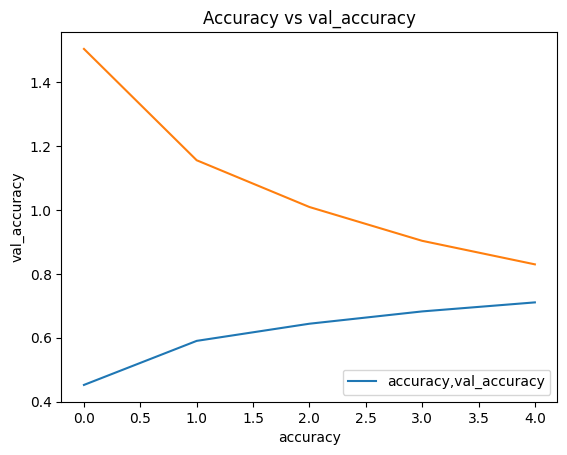

In [ ]:
import matplotlib.pyplot as plt
plt.title("Accuracy vs val_accuracy")
plt.plot(his.history['accuracy'])
plt.plot(his.history['loss'])
plt.xlabel("accuracy")
plt.ylabel("val_accuracy")
plt.legend(['accuracy,val_accuracy'],loc='lower right')
plt.show()


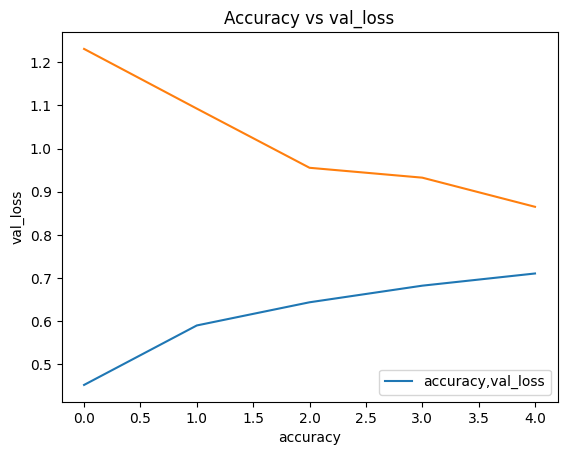

In [ ]:
import matplotlib.pyplot as plt
plt.title("Accuracy vs val_loss")
plt.plot(his.history['accuracy'])
plt.plot(his.history['val_loss'])
plt.xlabel("accuracy")
plt.ylabel("val_loss")
plt.legend(['accuracy,val_loss'],loc='lower right')
plt.show()
